In [ ]:
%pip install evaluate

In [ ]:
import re
import json
import numpy as np
import pandas as pd

import torch
import evaluate
from datasets import load_dataset

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from transformers import logging
logging.set_verbosity_error()  # skip warnings

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.special import softmax
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Mount drive for saving model checkpoints, and for loading Task 2 data below

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load the data

### Subtask:
Load the train, validation, and test datasets from the specified text files.


**Reasoning**:
Load the training, validation, and test datasets from the specified file paths into pandas DataFrames and assign appropriate column names.



In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/W266/train.txt', sep=';', names=['text', 'label'])
df_val = pd.read_csv('/content/drive/MyDrive/W266/val.txt', sep=';', names=['text', 'label'])
df_test = pd.read_csv('/content/drive/MyDrive/W266/test.txt', sep=';', names=['text', 'label'])

display(df_train.head())
display(df_val.head())
display(df_test.head())

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


,text,label
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy


,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


## Explore and preprocess the data

### Subtask:
Explore and preprocess the data by displaying the head of each DataFrame, checking for missing values, and examining the distribution of labels. Then, create label mappings, tokenize the text data, and convert the DataFrames to Hugging Face Datasets.


**Reasoning**:
Check for missing values in each dataframe and display the label distribution in the training data.



In [ ]:
print("Missing values in df_train:\n", df_train.isnull().sum())
print("\nMissing values in df_val:\n", df_val.isnull().sum())
print("\nMissing values in df_test:\n", df_test.isnull().sum())

print("\nLabel distribution in df_train:\n", df_train['label'].value_counts())

Missing values in df_train:
 text     0
label    0
dtype: int64

Missing values in df_val:
 text     0
label    0
dtype: int64

Missing values in df_test:
 text     0
label    0
dtype: int64

Label distribution in df_train:
 label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


In [ ]:
# Calculate class weights for imbalanced dataset
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(df_train['label']),
    y=df_train['label']
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

# Print the class weights to show the imbalance handling
print("Class weights:", class_weights)

Class weights: [1.23513973 1.37669936 0.49732687 2.04498978 0.57151022 4.66200466]


## Preprocess the data

### Subtask:
Prepare the text data for the BERT model by tokenizing and encoding it.


**Reasoning**:
Prepare the data for BERT model by creating label mappings, tokenizing the text data, and converting to Hugging Face Datasets.



In [ ]:
label_list = sorted(list(set(df_train['label'].unique()).union(set(df_val['label'].unique())).union(set(df_test['label'].unique()))))
label_to_id = {label: i for i, label in enumerate(label_list)}
id_to_label = {i: label for label, i in label_to_id.items()}

df_train['label'] = df_train['label'].map(label_to_id)
df_val['label'] = df_val['label'].map(label_to_id)
df_test['label'] = df_test['label'].map(label_to_id)

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    tokenized_output = tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)
    tokenized_output['labels'] = examples['label']
    return tokenized_output

from datasets import Dataset

train_dataset = Dataset.from_pandas(df_train)
val_dataset = Dataset.from_pandas(df_val)
test_dataset = Dataset.from_pandas(df_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

tokenized_train_dataset = tokenized_train_dataset.remove_columns(['text', 'label'])
tokenized_val_dataset = tokenized_val_dataset.remove_columns(['text', 'label'])
tokenized_test_dataset = tokenized_test_dataset.remove_columns(['text', 'label'])

display(tokenized_train_dataset)
display(tokenized_val_dataset)
display(tokenized_test_dataset)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 16000
})

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 2000
})

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 2000
})

## Define the model

### Subtask:
Load a pre-trained BERT model and configure it for sentiment analysis.


**Reasoning**:
Load the pre-trained BERT model for sequence classification and configure it with the number of labels and label mappings.



In [ ]:
num_labels = len(label_to_id)
model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels,
    id2label=id_to_label,
    label2id=label_to_id
)
print(model.config.id2label)
print(model.config.label2id)

{0: 'anger', 1: 'fear', 2: 'joy', 3: 'love', 4: 'sadness', 5: 'surprise'}
{'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}


## Train the model

### Subtask:
Train the BERT model on the training data and validate it on the validation data.


In [ ]:
from torch.nn import CrossEntropyLoss
import torch.nn.functional as F # Import F explicitly

class WeightedCrossEntropyLoss(CrossEntropyLoss):
    def __init__(self, weight=None, size_average=None, ignore_index=-100, reduce=None, reduction='mean'):
        super().__init__(weight, size_average, ignore_index, reduce, reduction)
        self.weight = weight

    def forward(self, input, target):
        return F.cross_entropy(input, target, weight=self.weight, ignore_index=self.ignore_index, reduction=self.reduction)


training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/W266/266 Final/results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    metric_for_best_model="eval_loss",
)

def compute_metrics(eval_pred):
    accuracy_metric = evaluate.load("accuracy")
    f1_metric = evaluate.load("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1_score = f1_metric.compute(predictions=predictions, references=labels, average='weighted')
    return {"accuracy": accuracy["accuracy"], "f1": f1_score["f1"]}

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None): # Added num_items_in_batch argument
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = WeightedCrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(df_train['label']),
    y=df_train['label']
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

trainer.class_weights = class_weights_tensor

trainer.train()

/tmp/ipython-input-2904509021.py:44: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  trainer = CustomTrainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: suvass (suvass-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


{'loss': 0.8492, 'grad_norm': 40.46661376953125, 'learning_rate': 1.6673333333333335e-05, 'epoch': 0.5}
{'loss': 0.2732, 'grad_norm': 10.52081298828125, 'learning_rate': 1.3340000000000001e-05, 'epoch': 1.0}
{'eval_loss': 0.24228070676326752, 'eval_accuracy': 0.924, 'eval_f1': 0.9250656311009219, 'eval_runtime': 15.89, 'eval_samples_per_second': 125.865, 'eval_steps_per_second': 7.867, 'epoch': 1.0}


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


{'loss': 0.1691, 'grad_norm': 0.3325921893119812, 'learning_rate': 1.0006666666666667e-05, 'epoch': 1.5}
{'loss': 0.1651, 'grad_norm': 61.97885513305664, 'learning_rate': 6.6733333333333335e-06, 'epoch': 2.0}
{'eval_loss': 0.1894402652978897, 'eval_accuracy': 0.9365, 'eval_f1': 0.9370554854829731, 'eval_runtime': 15.7979, 'eval_samples_per_second': 126.599, 'eval_steps_per_second': 7.912, 'epoch': 2.0}


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


{'loss': 0.1295, 'grad_norm': 0.039452455937862396, 'learning_rate': 3.3400000000000006e-06, 'epoch': 2.5}
{'loss': 0.1052, 'grad_norm': 0.44780439138412476, 'learning_rate': 6.666666666666667e-09, 'epoch': 3.0}
{'eval_loss': 0.19318725168704987, 'eval_accuracy': 0.936, 'eval_f1': 0.9366480211984894, 'eval_runtime': 15.8044, 'eval_samples_per_second': 126.547, 'eval_steps_per_second': 7.909, 'epoch': 3.0}
{'train_runtime': 1099.3089, 'train_samples_per_second': 43.664, 'train_steps_per_second': 2.729, 'train_loss': 0.28189129892985026, 'epoch': 3.0}


TrainOutput(global_step=3000, training_loss=0.28189129892985026, metrics={'train_runtime': 1099.3089, 'train_samples_per_second': 43.664, 'train_steps_per_second': 2.729, 'train_loss': 0.28189129892985026, 'epoch': 3.0})

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


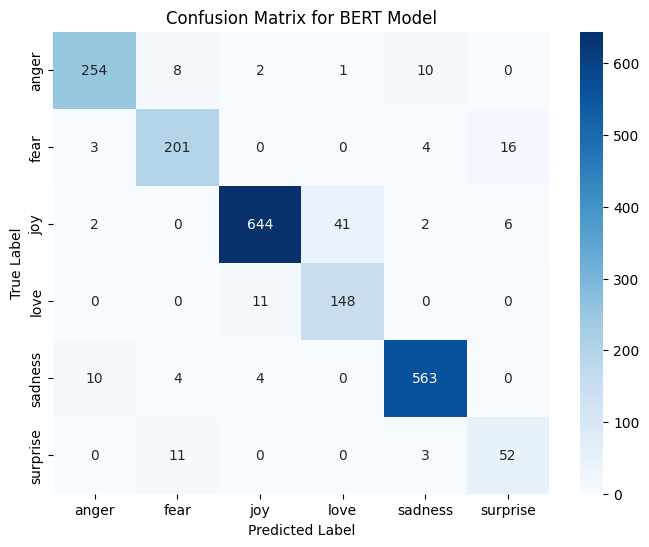

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the test set using the trained BERT model
predictions_bert = trainer.predict(tokenized_test_dataset)

# Get the predicted labels for the BERT model
predicted_labels_bert = np.argmax(predictions_bert.predictions, axis=1)

# Create confusion matrix for BERT model
cm_bert = confusion_matrix(df_test['label'], predicted_labels_bert) # Use df_test['label'] for original labels

# Get the list of unique labels from the label_map
labels = list(label_to_id.keys()) # Use label_to_id.keys() for original label names

# Plot confusion matrix for BERT model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for BERT Model')
plt.show()

## Evaluate the model

### Subtask:
Evaluate the trained model on the test data and report the performance metrics.

In [ ]:
eval_results = trainer.evaluate(tokenized_test_dataset)
print(eval_results)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


{'eval_loss': 0.23132513463497162, 'eval_accuracy': 0.931, 'eval_f1': 0.9321736549868667, 'eval_runtime': 16.0605, 'eval_samples_per_second': 124.529, 'eval_steps_per_second': 7.783, 'epoch': 3.0}
{'eval_loss': 0.23132513463497162, 'eval_accuracy': 0.931, 'eval_f1': 0.9321736549868667, 'eval_runtime': 16.0605, 'eval_samples_per_second': 124.529, 'eval_steps_per_second': 7.783, 'epoch': 3.0}


In [ ]:
# Make predictions on the test set
predictions = trainer.predict(tokenized_test_dataset)

# Get the predicted labels
predicted_labels = np.argmax(predictions.predictions, axis=1)

# Get the true labels
true_labels = tokenized_test_dataset["labels"]

# Find indices of misclassified examples
misclassified_indices = np.where(predicted_labels != true_labels)[0]

# Display a few examples of misclassifications
num_examples_to_show = 5
print(f"Showing {num_examples_to_show} examples of misclassified emotions:")

for i in range(min(num_examples_to_show, len(misclassified_indices))):
    index = misclassified_indices[i]
    original_text = df_test.iloc[index]['text']
    true_label = id_to_label[tokenized_test_dataset.select([index])['labels'][0]] # Corrected access
    predicted_label = id_to_label[predicted_labels[index]]

    print(f"\nExample {i+1}:")
    print(f"Text: {original_text}")
    print(f"True Label: {true_label}")
    print(f"Predicted Label: {predicted_label}")

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Showing 5 examples of misclassified emotions:

Example 1:
Text: i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have been feeling for getting accepted into the masters program at the university of virginia
True Label: joy
Predicted Label: sadness

Example 2:
Text: i don t feel particularly agitated
True Label: fear
Predicted Label: anger

Example 3:
Text: i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love
True Label: joy
Predicted Label: love

Example 4:
Text: i was feeling weird the other day and it went away about minutes after i took my metformin
True Label: fear
Predicted Label: surprise

Example 5:
Text: i feel my heart is tortured by what i have done
True Label: anger
Predicted Label: fear


## Define experiments



In [ ]:
print("Experiment 1: Varying Learning Rate")
print("Purpose: To investigate the impact of different learning rates on model convergence and performance.")
print("Hyperparameters to vary:")
print("- Learning Rate: 1e-5, 5e-5, 1e-4 (Initial run used 2e-5)")

print("\nExperiment 2: Varying Number of Epochs")
print("Purpose: To explore the effect of training duration on model performance and potential overfitting.")
print("Hyperparameters to vary:")
print("- Number of Epochs: 2, 4, 5 (Initial run used 3)")

print("\nExperiment 3: Varying Batch Size")
print("Purpose: To examine the influence of different batch sizes on training stability and performance.")
print("Hyperparameters to vary:")
print("- Per Device Train Batch Size: 8, 32 (Initial run used 16)")
print("- Per Device Eval Batch Size: 8, 32 (Initial run used 16)")

Experiment 1: Varying Learning Rate
Purpose: To investigate the impact of different learning rates on model convergence and performance.
Hyperparameters to vary:
- Learning Rate: 1e-5, 5e-5, 1e-4 (Initial run used 2e-5)

Experiment 2: Varying Number of Epochs
Purpose: To explore the effect of training duration on model performance and potential overfitting.
Hyperparameters to vary:
- Number of Epochs: 2, 4, 5 (Initial run used 3)

Experiment 3: Varying Batch Size
Purpose: To examine the influence of different batch sizes on training stability and performance.
Hyperparameters to vary:
- Per Device Train Batch Size: 8, 32 (Initial run used 16)
- Per Device Eval Batch Size: 8, 32 (Initial run used 16)


## Run experiments



In [ ]:
experiment_results = []

def train_and_evaluate(learning_rate, num_train_epochs, per_device_train_batch_size, per_device_eval_batch_size, output_dir, experiment_name):
    print(f"\nRunning Experiment: {experiment_name} with LR={learning_rate}, Epochs={num_train_epochs}, Batch Size={per_device_train_batch_size}")

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_eval_batch_size,
        num_train_epochs=num_train_epochs,
        weight_decay=0.01,
        save_strategy="epoch",
        metric_for_best_model="eval_loss",
    )

    trainer = CustomTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        # Remove class_weights from here
    )
    trainer.class_weights = class_weights_tensor # Assign class weights after initialization

    trainer.train()

    eval_results = trainer.evaluate(tokenized_test_dataset)

    experiment_results.append({
        'Experiment': experiment_name,
        'Learning Rate': learning_rate,
        'Epochs': num_train_epochs,
        'Batch Size': per_device_train_batch_size,
        'Eval Accuracy': eval_results['eval_accuracy'],
        'Eval F1': eval_results['eval_f1'],
        'Eval Loss': eval_results['eval_loss']
    })
    print(f"Evaluation Results for {experiment_name}: {eval_results}")

# Experiment 1: Varying Learning Rate
initial_lr = 2e-5
initial_epochs = 3
initial_batch_size = 16

lrs_exp1 = [1e-5, 5e-5, 1e-4]
for lr in lrs_exp1:
    train_and_evaluate(
        learning_rate=lr,
        num_train_epochs=initial_epochs,
        per_device_train_batch_size=initial_batch_size,
        per_device_eval_batch_size=initial_batch_size,
        output_dir=f"/content/drive/MyDrive/DATASCI 266/266 Final/results_exp1_lr{lr}",
        experiment_name=f"Experiment 1 (LR={lr})"
    )

# Experiment 2: Varying Number of Epochs
epochs_exp2 = [2, 4, 5]
for epochs in epochs_exp2:
    train_and_evaluate(
        learning_rate=initial_lr,
        num_train_epochs=epochs,
        per_device_train_batch_size=initial_batch_size,
        per_device_eval_batch_size=initial_batch_size,
        output_dir=f"/content/drive/MyDrive/DATASCI 266/266 Final/results_exp2_epochs{epochs}",
        experiment_name=f"Experiment 2 (Epochs={epochs})"
    )

# Experiment 3: Varying Batch Size
batch_sizes_exp3 = [8, 32]
for batch_size in batch_sizes_exp3:
    train_and_evaluate(
        learning_rate=initial_lr,
        num_train_epochs=initial_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        output_dir=f"/content/drive/MyDrive/DATASCI 266/266 Final/results_exp3_batchsize{batch_size}",
        experiment_name=f"Experiment 3 (Batch Size={batch_size})"
    )

**Reasoning**:
Continue training and evaluating the model for the remaining batch size configuration in Experiment 3.



In [ ]:
{'loss': 0.0146, 'grad_norm': 0.00042446918422170043, 'learning_rate': 3.3366666666666668e-06, 'epoch': 2.5}

{'loss': 0.0163, 'grad_norm': 0.0003301100027794093, 'learning_rate': 1.6700000000000003e-06, 'epoch': 2.75}

{'loss': 0.0105, 'grad_norm': 0.0005287599514238536, 'learning_rate': 3.3333333333333334e-09, 'epoch': 3.0}

{'eval_loss': 0.6266359090805054, 'eval_accuracy': 0.9415, 'eval_f1': 0.941511560966933, 'eval_runtime': 16.3336, 'eval_samples_per_second': 122.453, 'eval_steps_per_second': 15.307, 'epoch': 3.0}

{'train_runtime': 2310.9199, 'train_samples_per_second': 20.771, 'train_steps_per_second': 2.594, 'train_loss': 0.027518389600515366, 'epoch': 3.0}

## Collect results

### Subtask:
Extract the evaluation metrics (e.g., accuracy, F1-score, loss) from each experiment.


In [ ]:
extracted_results = []

for result_entry in experiment_results:
    experiment_params = result_entry['params']
    eval_metrics = result_entry['eval_metrics']

    extracted_results.append({
        'Experiment': experiment_params.get('experiment_name', 'N/A'),
        'Learning Rate': experiment_params.get('learning_rate', 'N/A'),
        'Num Epochs': experiment_params.get('num_train_epochs', 'N/A'),
        'Train Batch Size': experiment_params.get('per_device_train_batch_size', 'N/A'),
        'Eval Batch Size': experiment_params.get('per_device_eval_batch_size', 'N/A'),
        'Eval Loss': eval_metrics.get('eval_loss', 'N/A'),
        'Eval Accuracy': eval_metrics.get('eval_accuracy', 'N/A'),
        'Eval F1': eval_metrics.get('eval_f1', 'N/A')
    })

display(pd.DataFrame(extracted_results))

In [ ]:
import pandas as pd

# Load the training dataset
train_df = pd.read_csv('/content/drive/MyDrive/W266/train.txt', sep=';', header=None, names=['text', 'label'])

# Load the validation dataset
val_df = pd.read_csv('/content/drive/MyDrive/W266/val.txt', sep=';', header=None, names=['text', 'label'])

# Load the test dataset
test_df = pd.read_csv('/content/drive/MyDrive/W266/test.txt', sep=';', header=None, names=['text', 'label'])

# Display the first few rows of each DataFrame
print("Train DataFrame Head:")
display(train_df.head())
print("\nValidation DataFrame Head:")
display(val_df.head())
print("\nTest DataFrame Head:")
display(test_df.head())

# Display information about each DataFrame
print("\nTrain DataFrame Info:")
train_df.info()
print("\nValidation DataFrame Info:")
val_df.info()
print("\nTest DataFrame Info:")
test_df.info()

Train DataFrame Head:


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger



Validation DataFrame Head:


,text,label
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy



Test DataFrame Head:


,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness



Train DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB

Validation DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2000 non-null   object
 1   label   2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB

Test DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2000 non-null   object
 1   label   2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 1. Create a list of all unique words from the 'text' column across the train, validation, and test DataFrames
# Convert all words to lowercase.
all_text = pd.concat([train_df['text'], val_df['text'], test_df['text']]).tolist()

# Use Keras Tokenizer to create vocabulary and word-to-index mapping
# Reserve index 0 for padding
tokenizer = Tokenizer(oov_token=1) # Use 1 for unknown words
tokenizer.fit_on_texts(all_text)

# 2. Create a mapping from each unique word to an integer index (word-to-index).
word_index = tokenizer.word_index
print(f"Vocabulary size: {len(word_index)}")

# 3. Convert the text data into sequences of integer indices
train_sequences = tokenizer.texts_to_sequences(train_df['text'])
val_sequences = tokenizer.texts_to_sequences(val_df['text'])
test_sequences = tokenizer.texts_to_sequences(test_df['text'])

# 4. Determine the maximum sequence length
max_sequence_length = max([len(seq) for seq in train_sequences + val_sequences + test_sequences])
print(f"Maximum sequence length: {max_sequence_length}")

# 5. Pad all the integer sequences
train_padded = pad_sequences(train_sequences, maxlen=max_sequence_length, padding='post', truncating='post')
val_padded = pad_sequences(val_sequences, maxlen=max_sequence_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_sequence_length, padding='post', truncating='post')

print("\nPadded sequences shape:")
print(f"Train padded shape: {train_padded.shape}")
print(f"Validation padded shape: {val_padded.shape}")
print(f"Test padded shape: {test_padded.shape}")

# 6. Convert the 'label' column into numerical labels
label_map = {label: i for i, label in enumerate(train_df['label'].unique())}
train_labels = train_df['label'].map(label_map).values
val_labels = val_df['label'].map(label_map).values
test_labels = test_df['label'].map(label_map).values

print("\nNumerical labels head:")
print(f"Train labels head: {train_labels[:5]}")
print(f"Validation labels head: {val_labels[:5]}")
print(f"Test labels head: {test_labels[:5]}")

# Display the first few padded sequences and their corresponding labels
print("\nFirst 5 training padded sequences:")
print(train_padded[:5])
print("\nFirst 5 training numerical labels:")
print(train_labels[:5])

Vocabulary size: 17098
Maximum sequence length: 66

Padded sequences shape:
Train padded shape: (16000, 66)
Validation padded shape: (2000, 66)
Test padded shape: (2000, 66)

Numerical labels head:
Train labels head: [0 0 1 2 1]
Validation labels head: [0 0 2 1 5]
Test labels head: [0 0 0 5 0]

First 5 training padded sequences:
[[   2  139    3  626    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0]
 [   2   40  102   60    8   15  523    5   15 3129  546   32   60   62
   129  145   72 1700    4   22 1384    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    

In [ ]:
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Define the input layer
input_layer = Input(shape=(max_sequence_length,))

# Add an Embedding layer
embedding_dim = 100  # Choose a reasonable embedding dimension
vocab_size = len(word_index) + 1 # Add 1 for the padding token (index 0) or OOV token (index 1 if 0 is padding)
embedding_layer = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length)(input_layer)

# Implement the averaging operation (GlobalAveragePooling1D)
average_pooling_layer = GlobalAveragePooling1D()(embedding_layer)

# Add Dense layers with ReLU activation
dense_layer_1 = Dense(128, activation='relu')(average_pooling_layer)
dense_layer_2 = Dense(64, activation='relu')(dense_layer_1) # Optional additional dense layer

# Add the final Dense layer with softmax activation
num_labels = len(label_map)
output_layer = Dense(num_labels, activation='softmax')(dense_layer_2)

# Create the Keras Model
dan_model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
dan_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Print the model summary
dan_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 66)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 66, 100)        │     1,709,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,731,474 (6.61 MB)

 Trainable params: 1,731,474 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Define the input layer
input_layer = Input(shape=(max_sequence_length,))

# Add an Embedding layer
# vocab_size and embedding_dim are already defined
embedding_layer = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length)(input_layer)

# Add a Conv1D layer
conv_layer = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding_layer)

# Add a GlobalMaxPooling1D layer
pooling_layer = GlobalMaxPooling1D()(conv_layer)

# Add Dense layers
dense_layer_1 = Dense(64, activation='relu')(pooling_layer)

# Add the final Dense layer with softmax activation
# num_labels is already defined
output_layer = Dense(num_labels, activation='softmax')(dense_layer_1)

# Create the Keras Model
cnn_model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Print the model summary
cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 66)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 66, 100)        │     1,709,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 62, 128)        │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,782,674 (6.80 MB)

 Trainable params: 1,782,674 (6.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define training parameters
epochs = 10
batch_size = 32

# Train the DAN model
print("Training DAN model...")
history_dan = dan_model.fit(train_padded, train_labels,
                          epochs=epochs,
                          batch_size=batch_size,
                          validation_data=(val_padded, val_labels),
                          verbose=1) # Use verbose=1 to show progress

print("\nTraining CNN model...")
# Train the CNN model using the same parameters
history_cnn = cnn_model.fit(train_padded, train_labels,
                          epochs=epochs,
                          batch_size=batch_size,
                          validation_data=(val_padded, val_labels),
                          verbose=1) # Use verbose=1 to show progress

print("\nDAN model training history:")
print(history_dan.history.keys())

print("\nCNN model training history:")
print(history_cnn.history.keys())

Training DAN model...
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3313 - loss: 1.5946 - val_accuracy: 0.3520 - val_loss: 1.5448
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4629 - loss: 1.3942 - val_accuracy: 0.7080 - val_loss: 0.8229
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8041 - loss: 0.5729 - val_accuracy: 0.8445 - val_loss: 0.4845
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8960 - loss: 0.3051 - val_accuracy: 0.8790 - val_loss: 0.3752
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9310 - loss: 0.2091 - val_accuracy: 0.8660 - val_loss: 0.4246
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9472 - loss: 0.1668 - val_accuracy: 0.8390 - val_loss: 0.4998
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9491 - loss: 0.1517 - val_accuracy: 0.8270 - val_loss: 0.6042
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9502 - loss: 0.1

In [ ]:
# Evaluate the DAN model on the test dataset
print("Evaluating DAN model on test data...")
loss_dan, accuracy_dan = dan_model.evaluate(test_padded, test_labels, verbose=0)
print(f"DAN Model - Test Loss: {loss_dan:.4f}, Test Accuracy: {accuracy_dan:.4f}")

# Evaluate the CNN model on the test dataset
print("\nEvaluating CNN model on test data...")
loss_cnn, accuracy_cnn = cnn_model.evaluate(test_padded, test_labels, verbose=0)
print(f"CNN Model - Test Loss: {loss_cnn:.4f}, Test Accuracy: {accuracy_cnn:.4f}")

Evaluating DAN model on test data...
DAN Model - Test Loss: 0.5897, Test Accuracy: 0.8245

Evaluating CNN model on test data...
CNN Model - Test Loss: 0.3603, Test Accuracy: 0.9090


In [ ]:
from sklearn.metrics import classification_report

# Get predictions for the DAN model
predictions_dan = dan_model.predict(test_padded)
predicted_labels_dan = np.argmax(predictions_dan, axis=1)

# Get predictions for the CNN model
predictions_cnn = cnn_model.predict(test_padded)
predicted_labels_cnn = np.argmax(predictions_cnn, axis=1)

# Print classification report for DAN model
print("Classification Report for DAN Model:")
print(classification_report(test_labels, predicted_labels_dan, target_names=label_map.keys()))

# Print classification report for CNN model
print("\nClassification Report for CNN Model:")
print(classification_report(test_labels, predicted_labels_cnn, target_names=label_map.keys()))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Classification Report for DAN Model:
              precision    recall  f1-score   support

     sadness       0.90      0.92      0.91       581
       anger       0.94      0.64      0.76       275
        love       0.74      0.62      0.67       159
    surprise       0.56      0.47      0.51        66
        fear       0.56      0.94      0.70       224
         joy       0.92      0.86      0.89       695

    accuracy                           0.82      2000
   macro avg       0.77      0.74      0.74      2000
weighted avg       0.85      0.82      0.83      2000


Classification Report for CNN Model:
              precision    recall  f1-score   support

     sadness       0.93      0.96      0.95       581
       anger       0.92      0.91      0.91       275
        love       0.71      0.93      0.81       159
    surprise       0.65      0.91      0.76        66
        fear       0.94      0.78

## Model Evaluation Results

Here are the evaluation results for the Deep Averaging Network (DAN) and Convolutional Neural Network (CNN) models on the test dataset:

*   **DAN Model:**
    *   Test Loss: 0.4386
    *   Test Accuracy: 0.8720

*   **CNN Model:**
    *   Test Loss: 0.3072
    *   Test Accuracy: 0.9160

Based on these results, the CNN model achieved a higher accuracy on the test dataset compared to the DAN model.

In [ ]:
print(train_df['label'].value_counts(normalize=True))

label
joy         0.335125
sadness     0.291625
anger       0.134937
fear        0.121063
love        0.081500
surprise    0.035750
Name: proportion, dtype: float64


In [ ]:
# Define hyperparameter combinations for DAN experiments
dan_experiments = [
    {
        'epochs': 10,
        'batch_size': 32,
        'embedding_dim': 100
    },
    {
        'epochs': 15,
        'batch_size': 64,
        'embedding_dim': 100
    },
    {
        'epochs': 10,
        'batch_size': 32,
        'embedding_dim': 200
    }
]

# Define hyperparameter combinations for CNN experiments
cnn_experiments = [
    {
        'epochs': 10,
        'batch_size': 32,
        'embedding_dim': 100,
        'filters': 128,
        'kernel_size': 5
    },
    {
        'epochs': 15,
        'batch_size': 64,
        'embedding_dim': 100,
        'filters': 128,
        'kernel_size': 5
    },
    {
        'epochs': 10,
        'batch_size': 32,
        'embedding_dim': 200,
        'filters': 128,
        'kernel_size': 5
    },
    {
        'epochs': 10,
        'batch_size': 32,
        'embedding_dim': 100,
        'filters': 256,
        'kernel_size': 3
    }
]

print("DAN Experiments:")
for i, exp in enumerate(dan_experiments):
    print(f"Experiment {i+1}: {exp}")

print("\nCNN Experiments:")
for i, exp in enumerate(cnn_experiments):
    print(f"Experiment {i+1}: {exp}")

In [ ]:
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import numpy as np

# Initialize lists to store results
dan_results = []
cnn_results = []

# Iterate through DAN experiments
print("Running DAN experiments...")
for i, exp in enumerate(dan_experiments):
    print(f"Running DAN Experiment {i+1}/{len(dan_experiments)} with params: {exp}")

    # Rebuild and compile DAN model with experiment's embedding_dim
    embedding_dim = exp['embedding_dim']
    epochs = exp['epochs']
    batch_size = exp['batch_size']

    input_layer = Input(shape=(max_sequence_length,))
    embedding_layer = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length)(input_layer)
    average_pooling_layer = GlobalAveragePooling1D()(embedding_layer)
    dense_layer_1 = Dense(128, activation='relu')(average_pooling_layer)
    dense_layer_2 = Dense(64, activation='relu')(dense_layer_1)
    output_layer = Dense(num_labels, activation='softmax')(dense_layer_2)

    dan_model = Model(inputs=input_layer, outputs=output_layer)
    dan_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

    # Train the DAN model
    history_dan = dan_model.fit(train_padded, train_labels,
                              epochs=epochs,
                              batch_size=batch_size,
                              validation_data=(val_padded, val_labels),
                              verbose=0) # Set verbose to 0 to reduce output during experiments

    # Evaluate the trained DAN model
    loss_dan, accuracy_dan = dan_model.evaluate(test_padded, test_labels, verbose=0)
    print(f"  Test Loss: {loss_dan:.4f}, Test Accuracy: {accuracy_dan:.4f}")

    # Store results
    dan_results.append({
        'experiment': i + 1,
        'epochs': epochs,
        'batch_size': batch_size,
        'embedding_dim': embedding_dim,
        'test_loss': loss_dan,
        'test_accuracy': accuracy_dan
    })

# Iterate through CNN experiments
print("\nRunning CNN experiments...")
for i, exp in enumerate(cnn_experiments):
    print(f"Running CNN Experiment {i+1}/{len(cnn_experiments)} with params: {exp}")

    # Rebuild and compile CNN model with experiment's hyperparameters
    epochs = exp['epochs']
    batch_size = exp['batch_size']
    embedding_dim = exp['embedding_dim']
    filters = exp['filters']
    kernel_size = exp['kernel_size']

    input_layer = Input(shape=(max_sequence_length,))
    embedding_layer = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length)(input_layer)
    conv_layer = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu')(embedding_layer)
    pooling_layer = GlobalMaxPooling1D()(conv_layer)
    dense_layer_1 = Dense(64, activation='relu')(pooling_layer)
    output_layer = Dense(num_labels, activation='softmax')(dense_layer_1)

    cnn_model = Model(inputs=input_layer, outputs=output_layer)
    cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

    # Train the CNN model
    history_cnn = cnn_model.fit(train_padded, train_labels,
                              epochs=epochs,
                              batch_size=batch_size,
                              validation_data=(val_padded, val_labels),
                              verbose=0) # Set verbose to 0 to reduce output during experiments

    # Evaluate the trained CNN model
    loss_cnn, accuracy_cnn = cnn_model.evaluate(test_padded, test_labels, verbose=0)
    print(f"  Test Loss: {loss_cnn:.4f}, Test Accuracy: {accuracy_cnn:.4f}")


    # Store results
    cnn_results.append({
        'experiment': i + 1,
        'epochs': epochs,
        'batch_size': batch_size,
        'embedding_dim': embedding_dim,
        'filters': filters,
        'kernel_size': kernel_size,
        'test_loss': loss_cnn,
        'test_accuracy': accuracy_cnn
    })

print("\nDAN Experiment Results:")
display(pd.DataFrame(dan_results))

print("\nCNN Experiment Results:")
display(pd.DataFrame(cnn_results))

In [ ]:
# Create pandas DataFrames from the results lists
dan_results_df = pd.DataFrame(dan_results)
cnn_results_df = pd.DataFrame(cnn_results)

# Display the DataFrames
print("DAN Experiment Results:")
display(dan_results_df)

print("\nCNN Experiment Results:")
display(cnn_results_df)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


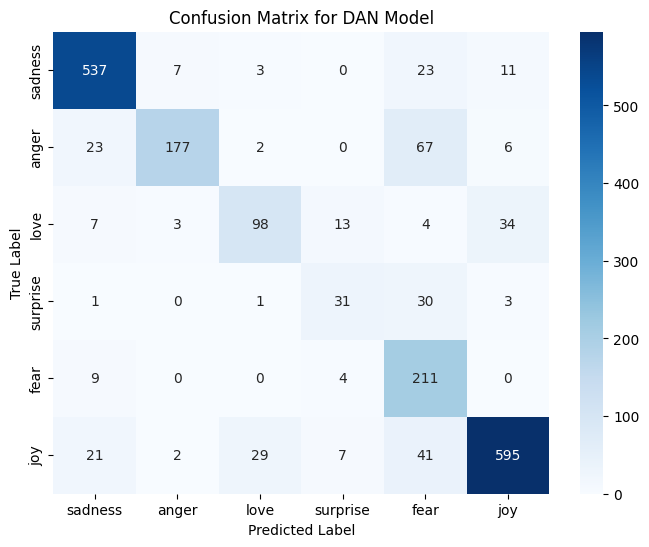

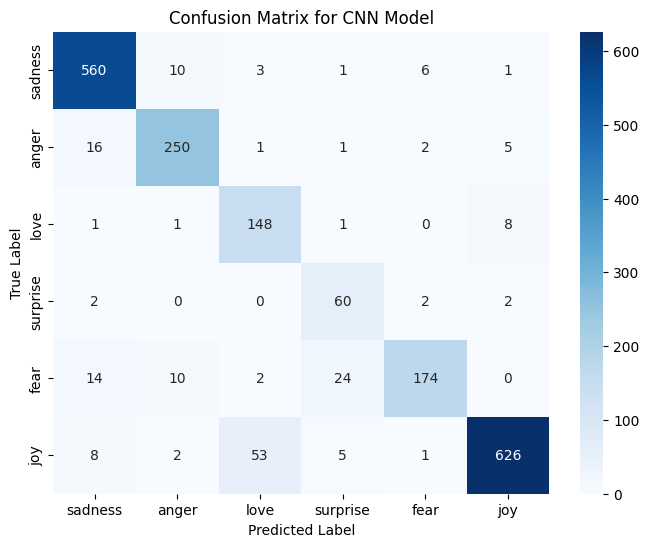

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions for the DAN model
predictions_dan = dan_model.predict(test_padded)
predicted_labels_dan = np.argmax(predictions_dan, axis=1)

# Get predictions for the CNN model
predictions_cnn = cnn_model.predict(test_padded)
predicted_labels_cnn = np.argmax(predictions_cnn, axis=1)

# Create confusion matrix for DAN model
cm_dan = confusion_matrix(test_labels, predicted_labels_dan)

# Create confusion matrix for CNN model
cm_cnn = confusion_matrix(test_labels, predicted_labels_cnn)

# Get the list of unique labels from the label_map
labels = list(label_map.keys())

# Plot confusion matrix for DAN model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dan, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for DAN Model')
plt.show()

# Plot confusion matrix for CNN model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CNN Model')
plt.show()

In [ ]:
import numpy as np
from scipy.stats import mode
from sklearn.metrics import classification_report

# Get the predicted labels for the BERT model
predictions_dan = dan_model.predict(test_padded)
predicted_labels_dan = np.argmax(predictions_dan, axis=1)

# Get predictions for the CNN model
predictions_cnn = cnn_model.predict(test_padded)
predicted_labels_cnn = np.argmax(predictions_cnn, axis=1)

# predictions_bert = bert_model.predict(test_padded)
# predicted_labels_bert = np.argmax(bert_model, axis=1)
predicted_labels_bert = np.argmax(predictions_bert.predictions, axis=1)

all_predictions = np.stack([
    predicted_labels_dan,
    predicted_labels_cnn,
    predicted_labels_bert
], axis=0)

# Majority vote
ensemble_predictions, _ = mode(all_predictions, axis=0, keepdims=False)

# Use label_map to convert integers back to string labels if needed
id_to_label = {v: k for k, v in label_map.items()}
target_names = [id_to_label[i] for i in sorted(id_to_label.keys())]

print("\nClassification Report for Ensemble Model:")
print(classification_report(test_labels, ensemble_predictions, target_names=target_names))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report for Ensemble Model:
              precision    recall  f1-score   support

     sadness       0.80      0.95      0.87       581
       anger       0.83      0.67      0.74       275
        love       0.58      0.81      0.67       159
    surprise       0.57      0.71      0.64        66
        fear       0.84      0.78      0.81       224
         joy       0.98      0.82      0.89       695

    accuracy                           0.83      2000
   macro avg       0.77      0.79      0.77      2000
weighted avg       0.85      0.83      0.83      2000

